# Homework 1

| | |
|:--|:--|
| **Course** | Python Programming |
| **Assignment** | Homework 1 |
| **Student** | *(蕭本豫 / 411278018)* |
| **Date** | March 13, 2026 |

---

## Problem 1 — Two-Floor Elevator Logic Control

A two-floor elevator needs a control circuit to decide **when to move to the other floor**.

| Variable | Role | Value |
|:---:|:---|:---|
| `f` | 1st floor button | 1 = pushed,  0 = not pushed |
| `s` | 2nd floor button | 1 = pushed,  0 = not pushed |
| `p` | Present floor indicator | 1 = 1st floor,  0 = 2nd floor |
| `m` | Move output | 1 = move (change floor),  0 = stay |

### (a) Boolean Expression

The elevator should move only when there is a **request from the other floor**:

| Condition | Logic |
|:---|:---|
| On 1st floor (`p=1`) and 2nd floor button pressed (`s=1`) | $p \land s$ |
| On 2nd floor (`p=0`) and 1st floor button pressed (`f=1`) | $\lnot p \land f$ |

Combining both conditions with OR:

$$\boxed{m = (p \land s) \lor (\lnot p \land f)}$$

In [1]:
def move(f: int, s: int, p: int) -> int:
    """Return 1 (move) when there is a request from the other floor, else 0 (stay)"""
    return 1 if (p and s) or (not p and f) else 0

### (b) Circuit Diagram

The Boolean expression $m = (p \land s) \lor (\lnot p \land f)$ maps directly to the following gate-level circuit:

1. A **NOT** gate inverts `p` to produce $\lnot p$.
2. **AND gate 1** computes $\lnot p \land f$ — move down when on 2nd floor and 1st floor is requested.
3. **AND gate 2** computes $p \land s$ — move up when on 1st floor and 2nd floor is requested.
4. An **OR** gate combines both AND outputs to produce the final move signal `m`.

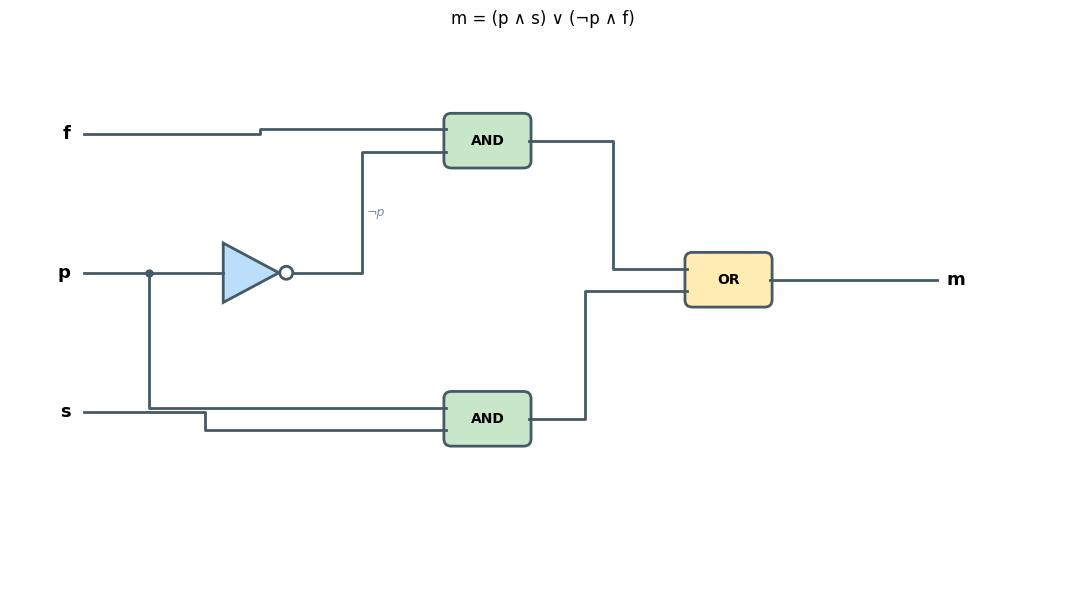

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(11, 6))
ax.set_xlim(-0.5, 11)
ax.set_ylim(-0.5, 5.5)
ax.set_aspect('equal')
ax.axis('off')

c_not  = '#BBDEFB'
c_and  = '#C8E6C9'
c_or   = '#FFECB3'
c_wire = '#455A64'
c_lbl  = '#78909C'
lw = 2
gate_w, gate_h = 0.9, 0.55

def wire(ax, pts):
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    ax.plot(xs, ys, color=c_wire, lw=lw)

def dot(ax, x, y):
    ax.plot(x, y, 'o', color=c_wire, markersize=5, zorder=5)

# ── Layout positions ─────────────────────────────────────
y_f, y_p, y_s = 4.4, 2.9, 1.4
y_and1, y_and2 = 4.05, 1.05
y_or   = 2.55
x_in, x_not, x_and, x_or, x_out = 0.3, 1.8, 4.2, 6.8, 9.5

# Gate port helpers: hi = upper input, lo = lower input
def hi(y):  return y + gate_h * 0.72
def lo(y):  return y + gate_h * 0.28
def mid(y): return y + gate_h * 0.50

# NOT gate center y aligns with p
y_not_mid = y_p

# ── Input labels ─────────────────────────────────────────
for lbl, y in [('f', y_f), ('p', y_p), ('s', y_s)]:
    ax.text(x_in - 0.15, y, lbl, ha='right', va='center', fontsize=13, fontweight='bold')

# ── NOT gate (triangle + bubble) ─────────────────────────
tri = np.array([[x_not,        y_not_mid + 0.32],
                [x_not + 0.60, y_not_mid],
                [x_not,        y_not_mid - 0.32]])
ax.add_patch(plt.Polygon(tri, closed=True, facecolor=c_not, edgecolor=c_wire, lw=lw))
ax.add_patch(Circle((x_not + 0.68, y_not_mid), 0.07,
                     facecolor='white', edgecolor=c_wire, lw=lw))
not_out_x = x_not + 0.75

# ── AND gates ────────────────────────────────────────────
for y in [y_and1, y_and2]:
    ax.add_patch(FancyBboxPatch((x_and, y), gate_w, gate_h,
                                boxstyle="round,pad=0.02,rounding_size=0.08",
                                facecolor=c_and, edgecolor=c_wire, lw=lw))
    ax.text(x_and + gate_w/2, mid(y), 'AND',
            ha='center', va='center', fontsize=10, fontweight='bold')

# ── OR gate ──────────────────────────────────────────────
ax.add_patch(FancyBboxPatch((x_or, y_or), gate_w, gate_h,
                             boxstyle="round,pad=0.02,rounding_size=0.08",
                             facecolor=c_or, edgecolor=c_wire, lw=lw))
ax.text(x_or + gate_w/2, mid(y_or), 'OR',
        ha='center', va='center', fontsize=10, fontweight='bold')

# ── Wires ────────────────────────────────────────────────
# Each gate now has distinct hi / lo input ports (no overlapping wires).

# f → AND1 upper input
wire(ax, [(x_in, y_f), (2.2, y_f), (2.2, hi(y_and1)), (x_and, hi(y_and1))])

# p → NOT gate (horizontal); branch at p_branch_x going down to AND2
p_branch_x = 1.0
wire(ax, [(x_in, y_p), (x_not, y_p)])           # p → NOT gate input
wire(ax, [(p_branch_x, y_p),
          (p_branch_x, hi(y_and2)),
          (x_and,      hi(y_and2))])             # p → AND2 upper input
dot(ax, p_branch_x, y_p)                        # junction dot

# NOT p → AND1 lower input
wire(ax, [(not_out_x, y_not_mid),
          (3.3, y_not_mid),
          (3.3, lo(y_and1)),
          (x_and, lo(y_and1))])
ax.text(3.35, (y_not_mid + lo(y_and1)) / 2, '¬p',
        ha='left', va='center', fontsize=9, color=c_lbl, style='italic')

# s → AND2 lower input
wire(ax, [(x_in, y_s), (1.6, y_s), (1.6, lo(y_and2)), (x_and, lo(y_and2))])

# AND1 output → OR upper input
wire(ax, [(x_and + gate_w, mid(y_and1)),
          (6.0, mid(y_and1)),
          (6.0, hi(y_or)),
          (x_or, hi(y_or))])

# AND2 output → OR lower input
wire(ax, [(x_and + gate_w, mid(y_and2)),
          (5.7, mid(y_and2)),
          (5.7, lo(y_or)),
          (x_or, lo(y_or))])

# OR output → m
wire(ax, [(x_or + gate_w, mid(y_or)), (x_out, mid(y_or))])

# ── Output label ─────────────────────────────────────────
ax.text(x_out + 0.1, mid(y_or), 'm',
        ha='left', va='center', fontsize=13, fontweight='bold')

plt.title('m = (p ∧ s) ∨ (¬p ∧ f)', fontsize=12)
plt.tight_layout()
plt.show()


### (c) Truth Table

All $2^3 = 8$ possible input combinations and their corresponding outputs:

In [3]:
import pandas as pd
from itertools import product

rows = []
for f, s, p in product([0, 1], repeat=3):
    m = move(f, s, p)
    rows.append({'f': f, 's': s, 'p': p, 'm': m})

df = pd.DataFrame(rows)
df.columns = ['f (1st btn)', 's (2nd btn)', 'p (floor)', 'm (move)']
df

,f (1st btn),s (2nd btn),p (floor),m (move)
0,0,0,0,0
1,0,0,1,0
2,0,1,0,0
3,0,1,1,1
4,1,0,0,1
5,1,0,1,0
6,1,1,0,1
7,1,1,1,1


---

## Problem 2 — Regular Expressions

### (a) IPv4 Address Detection

An **IPv4 address** is a 32-bit numeric address written as **4 decimal octets** (0–255) separated by periods, e.g. `192.168.1.1`.

Each octet is matched by:

$$\underbrace{25[0\text{-}5]}_{250\text{–}255} \;\Big|\; \underbrace{2[0\text{-}4][0\text{-}9]}_{200\text{–}249} \;\Big|\; \underbrace{[01]?[0\text{-}9][0\text{-}9]?}_{0\text{–}199}$$

The full pattern repeats this octet rule four times, joined by literal dots.

In [ ]:
import re

# Each octet: 25[0-5] | 2[0-4][0-9] | [01]?[0-9][0-9]?  (covers 0–255)
ipv4_pattern = (
    r'\b(?:(?:25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)\.){3}'
    r'(?:25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)\b'
)

def find_ipv4(text):
    return re.findall(ipv4_pattern, text)

# ── Verification ─────────────────────────────────────────
valid_cases   = ["192.168.1.1", "10.0.0.1", "0.0.0.0", "255.255.255.255"]
invalid_cases = ["256.1.1.1", "192.168.1.256", "999.0.0.1", "1.2.3"]

print(f"Pattern: {ipv4_pattern}\n")
print("Valid addresses (should all match):")
for addr in valid_cases:
    result = find_ipv4(addr)
    print(f"  {addr:<20} → {'✓ matched' if result else '✗ no match'}")

print("\nInvalid addresses (should not match):")
for addr in invalid_cases:
    result = find_ipv4(addr)
    print(f"  {addr:<20} → {'✗ matched (error)' if result else '✓ correctly rejected'}")

### (b) Taiwan Mobile Phone Number Detection

Taiwan mobile numbers follow this format:

| Part | Rule | Example |
|:---|:---|:---|
| Prefix | `09` followed by a digit 0–8 → covers **090–098** | `091`, `095` |
| Remaining | 7 more digits | `2345678` |
| Total length | **10 digits** | `0912345678` |

The pattern is: `09[0-8]` + `\d{7}`

In [ ]:
# Taiwan mobile: 090–098 prefix (3 digits) + 7 digits = 10 digits total
tw_mobile_pattern = r'\b09[0-8]\d{7}\b'

def find_tw_mobile(text):
    return re.findall(tw_mobile_pattern, text)

# ── Verification ─────────────────────────────────────────
valid_cases   = ["0912345678", "0901234567", "0987654321", "0956789012"]
invalid_cases = ["0991234567",   # 099 — out of range
                 "091234567",    # 9 digits — too short
                 "09123456789",  # 11 digits — too long
                 "0800123456"]   # not a mobile prefix

print(f"Pattern: {tw_mobile_pattern}\n")
print("Valid numbers (should all match):")
for num in valid_cases:
    result = find_tw_mobile(num)
    print(f"  {num:<15} → {'✓ matched' if result else '✗ no match'}")

print("\nInvalid numbers (should not match):")
for num in invalid_cases:
    result = find_tw_mobile(num)
    print(f"  {num:<15} → {'✗ matched (error)' if result else '✓ correctly rejected'}")